In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import h5py, os
import numpy as np
import matplotlib.pyplot as plt

import torch
from msi.flow_conductor import architecture
from msi.flow_conductor.likelihood_flow import LikelihoodFlow

from msfm.utils import prior, parameters, files, logger, observation

In [3]:
conf = files.load_config("/global/homes/a/athomsen/multiprobe-simulation-forward-model/configs/v9/linear_bias.yaml")

base_dir = "/pscratch/sd/a/athomsen/v11desy3/v9/linear_bias"
out_dir = "./v9"

with_lensing = True
with_clustering = False
params = ["Om", "s8", "w0", "Aia", "n_Aia"]
# params = ["Om", "s8"]

n_params = len(params)

In [4]:
loss = "mse"
# loss = "like"
# loss = "mutual(jsd)"
# loss = "mutual(dc)"
# loss = "mutual(var)"

grid_preds = np.load(f"./predictions/{loss}_grid_preds.npy")
grid_cosmos = np.load(f"./predictions/{loss}_grid_cosmos.npy")
fidu_preds = np.load(f"./predictions/{loss}_fidu_preds.npy")

if loss == "like":
    grid_preds = grid_preds[:,:n_params]
    fidu_preds = fidu_preds[:,:n_params]
    
label = loss

print(grid_preds.shape)
print(fidu_preds.shape)
print(grid_cosmos.shape)

(120000, 5)
(40000, 5)
(120000, 5)


# normalizing flow

In [5]:
# input dimensions
x_dim = grid_preds.shape[-1]
theta_dim = grid_cosmos.shape[-1]

# shared hyperparameters
context_embedding_dim = 32

embedding_net = architecture.get_context_embedding_net(
    context_dim=theta_dim,
    context_embedding_dim=context_embedding_dim,
    hidden_dim=64,
    n_blocks=3,
    dropout_probability=0.0,
    use_batch_norm=False,
)    

base_dist = architecture.get_normal_dist(
    feature_dim=x_dim,
)

transform = architecture.get_sigmoids_transform(
    feature_dim=x_dim,
    context_embedding_dim=context_embedding_dim,
    n_layers=4,
    hidden_dim=256,
    svd_kwargs={},
    sigmoids_kwargs={
        "n_sigmoids": 32,
        "num_blocks": 3,
        "dropout_probability": 0.0,
    }
)

# transform = architecture.get_lipschitz_transform(
#     feature_dim=x_dim,
#     context_embedding_dim=context_embedding_dim,
#     n_layers=5,
#     hidden_dim=128,
# )

model = LikelihoodFlow(
    params, 
    conf, 
    embedding_net=embedding_net,
    base_dist=base_dist,
    transform=transform,
    out_dir=out_dir, 
    label=label,
    load_existing=False,
    # load_existing=True,
)

24-08-22 06:22:43 likelihood_b INF   Set up the model directory ./v9/mse/likelihood_flow 
24-08-22 06:22:43 likelihood_f INF   Initialized the normalizing flow 
24-08-22 06:22:44 likelihood_f INF   Running on device cuda with default float torch.float32 
24-08-22 06:22:44 likelihood_f INF   Initializing fresh weights 


24-08-22 06:22:45 likelihood_f INF   Using a cosine annealing scheduler with lr_min 1e-05 and T_max 100 
100%|████████████████████████████|   | 100/100 [02:25<00:00,  1.46s/it]       lr: 1.00E-05, train: -4.64, vali: -4.51:  
24-08-22 06:25:11 likelihood_f INF   Saved the model to ./v9/mse/likelihood_flow/likelihood_flow.pt 


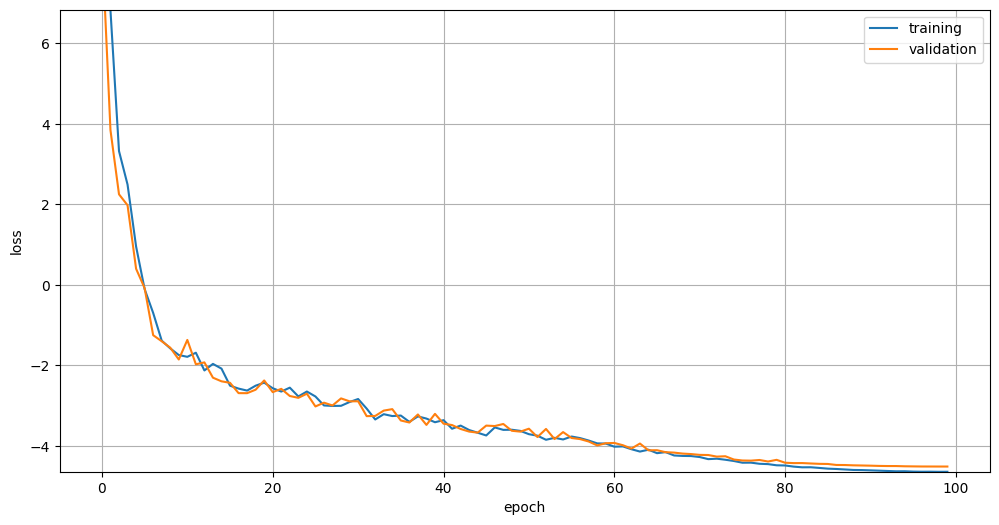

In [6]:
n_samples = 100_000
indices = np.random.randint(0, grid_preds.shape[0], n_samples)

# default to train from scratch with 4 permutations per grid point
model.fit(
    x=grid_preds,
    theta=grid_cosmos,
    # x=grid_preds[indices],
    # theta=grid_cosmos[indices],
    n_epochs=100,
    # dataset
    batch_size=10_000,
    vali_split=0.1,
    # optimizer
    learning_rate=1e-2,
    weight_decay=0.0,
    clip_by_global_norm=1.0,
    # scheduler
    scheduler_type="cosine",
    scheduler_kwargs={"eta_min": 1e-5},
    # early stopping
    n_patience_epochs=None,
    min_delta=1e-5,
    save_model=True,
)

### observation

In [7]:
i_obs = 0
# i_obs = np.argmin(np.sum(np.square(np.median(fidu_preds, axis=0, keepdims=True) - fidu_preds), axis=-1))
print(f"Using the example index {i_obs}")

obs_pred = fidu_preds[i_obs]

obs_point = {str(param): value for param, value in zip(params, parameters.get_fiducials(params))}
obs_label = f"fiducial_{i_obs}_{loss}"

# obs_pred = np.median(file_dict["fiducial/vali/pred"], axis=0)[:len(params)]
# obs_point = parameters.get_fiducials(params)
# obs_label = f"fiducial_median"

print(obs_pred)

Using the example index 0
[ 0.28450665  0.7425182  -1.025283    0.37150124 -0.48925406]


### MCMC

In [8]:
posterior_samples = model.sample_posterior(
    obs_pred,
    label=obs_label,
)

24-08-22 06:25:11      mcmc.py INF   Initial values in prior: True 
24-08-22 06:25:11      mcmc.py INF   Starting the burn in MCMC chain (100 steps) 
24-08-22 06:25:17      mcmc.py INF   Starting the main MCMC chain (500 steps) 


100%|██████████| 500/500 [00:27<00:00, 17.88it/s]

24-08-22 06:25:45      mcmc.py INF   Saved the MCMC chain to ./v9/mse/likelihood_flow/chain_fiducial_0_mse.npy 


### plotting

  0%|          | 0/15 [00:00<?, ?it/s]

  0%|          | 0/15 [00:00<?, ?it/s]

24-08-22 06:25:49  plotting.py INF   Saved the plot to ./v9/mse/likelihood_flow/contours_fiducial_0_mse.png 


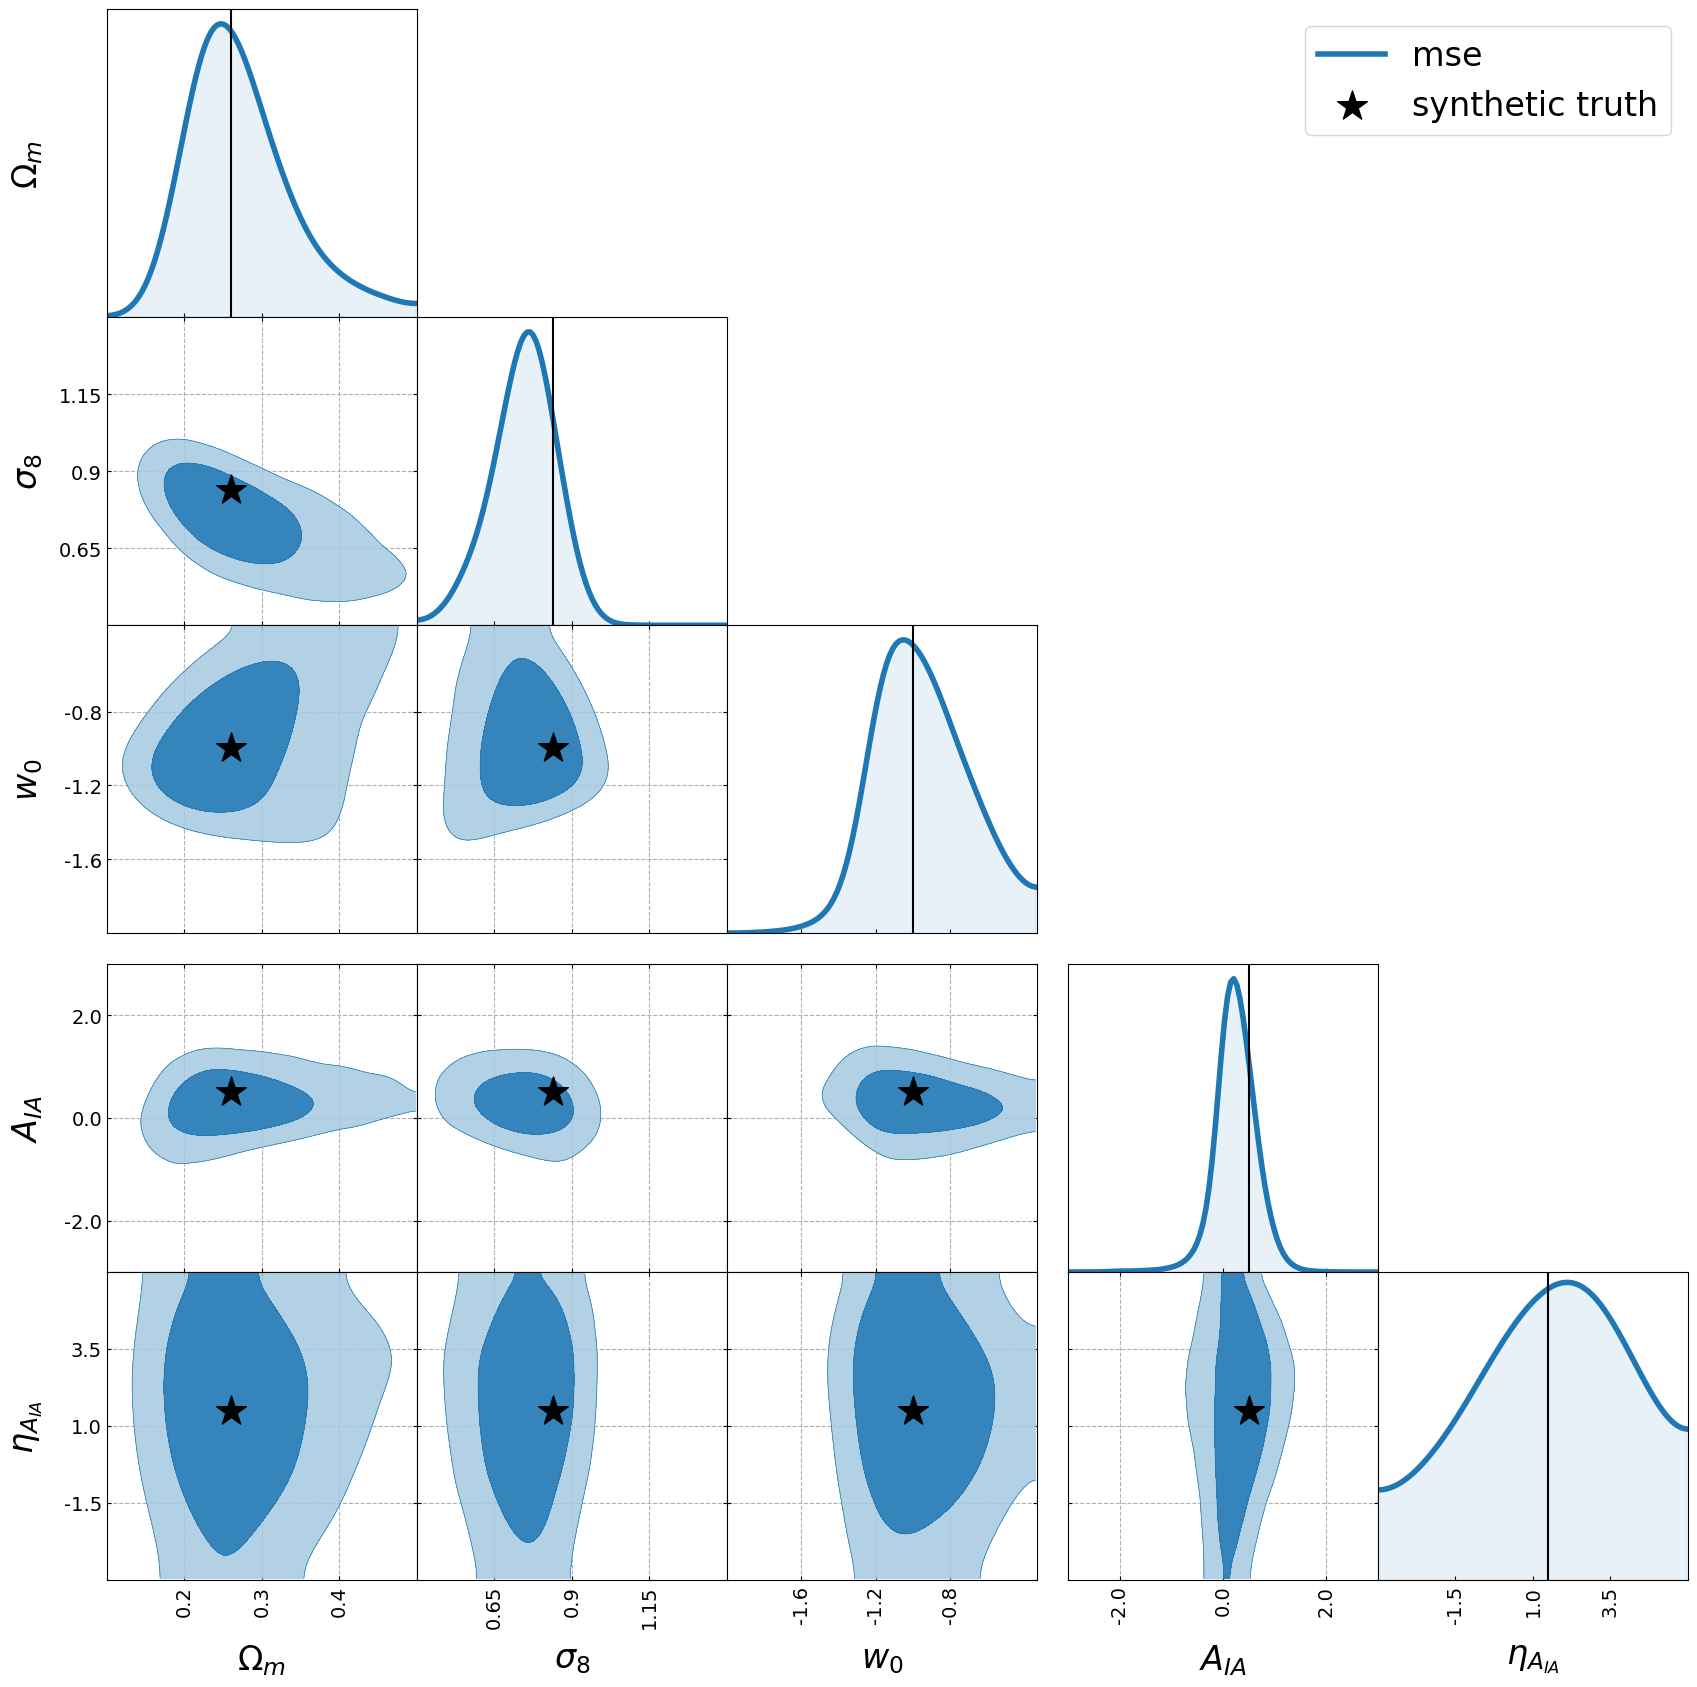

In [9]:
model.plot_contours(
    posterior_samples,
    with_des_chain=False,
    fiducial_point=obs_point,
    label=obs_label,
)